<a href="https://colab.research.google.com/github/Munaza-maker12/neurofive-ml-track/blob/main/heart_disease_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ❤️ Heart Disease Risk Prediction — End-to-End ML Capstone

**Author:** *(Munaza)*
**Goal:** Predict whether a patient is at risk of heart disease from routine clinical measurements (age, blood pressure, cholesterol, ECG results, etc.), and ship the model as a live, usable app.

This notebook follows the full ML workflow:
`Problem Definition → Data Cleaning → EDA → Feature Engineering → Model Training → Evaluation → Model Selection → Export for Deployment`

Dataset: UCI Heart Disease dataset (Cleveland subset, 303 patients, 13 clinical features).


## 1. Setup & Imports

In [1]:
# If running in Google Colab, uncomment the line below to install missing packages
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)
import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42


## 2. Problem Definition

**Business framing:** Cardiovascular disease is one of the leading causes of death worldwide. A lightweight, explainable model that flags high-risk patients from a handful of routine measurements (the kind collected in almost any check-up) can help clinics **triage patients for further cardiac testing** faster and cheaper than sending everyone for an angiogram.

**ML framing:** Binary classification.
- **Input:** 13 clinical features (age, sex, chest pain type, resting blood pressure, cholesterol, fasting blood sugar, resting ECG, max heart rate, exercise-induced angina, ST depression, slope, number of major vessels, thalassemia)
- **Output:** `target` — 1 = presence of heart disease, 0 = no heart disease
- **Success metric:** Since missing a sick patient (false negative) is far more costly than a false alarm, we optimize primarily for **Recall** and **ROC-AUC**, while keeping accuracy reasonable.


## 3. Load & Clean Data

In [4]:
df = pd.read_csv("heart.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# Data quality checks
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)


Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows: 1

Data types:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [6]:
# Drop exact duplicates (if any) — keep data clean
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after de-duplication:", df.shape)


Shape after de-duplication: (302, 14)


In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


## 4. Exploratory Data Analysis (EDA)

We look at: class balance, distributions of key numeric features, and how features relate to the target.


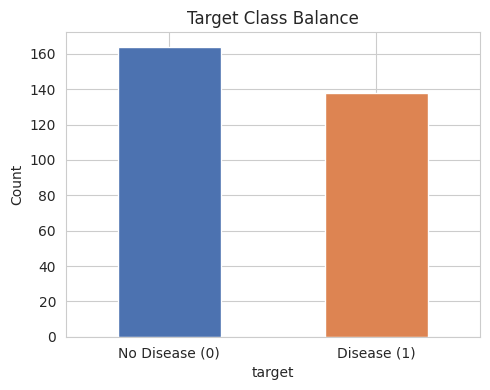

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
df['target'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
ax.set_title('Target Class Balance')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


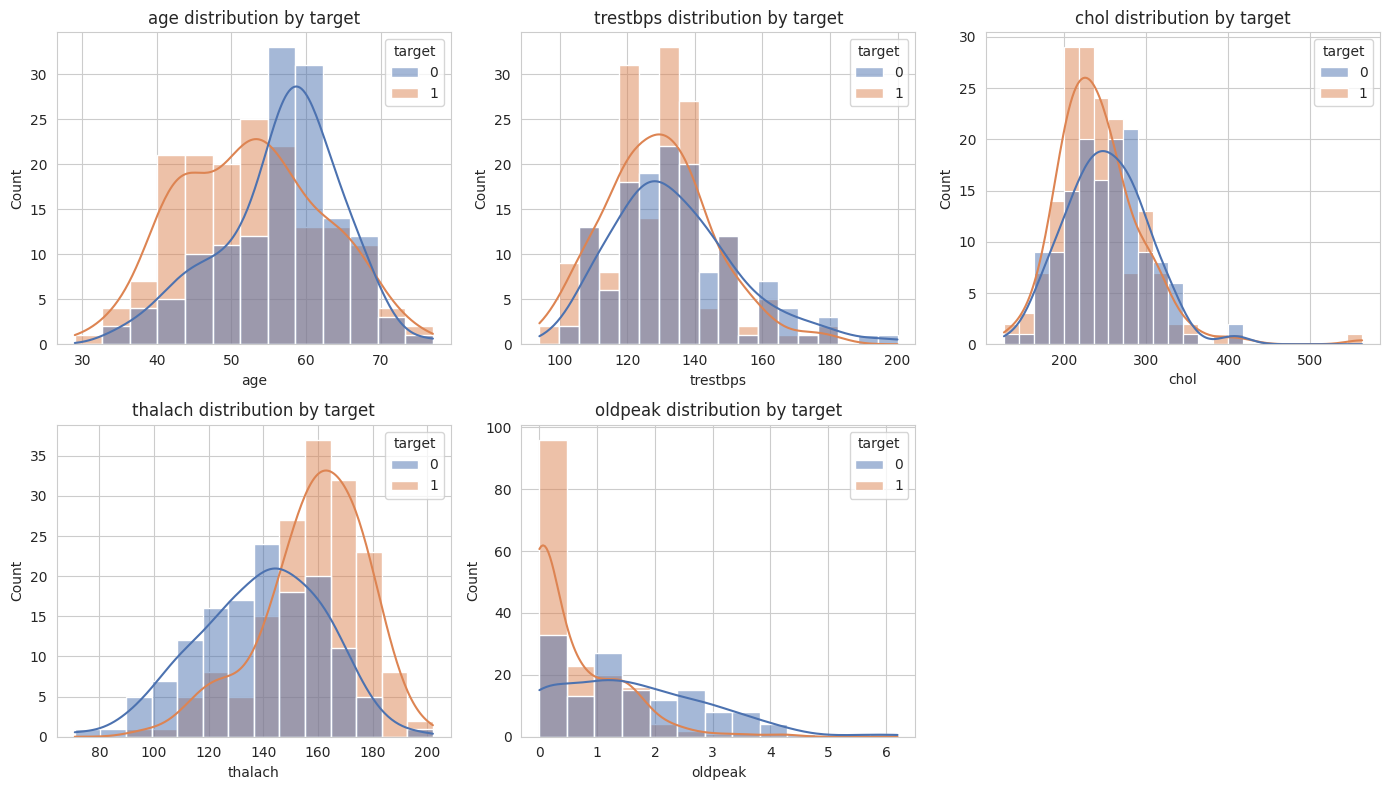

In [9]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=axes[i], palette=['#4C72B0', '#DD8452'])
    axes[i].set_title(f'{col} distribution by target')
axes[-1].axis('off')
plt.tight_layout()
plt.show()


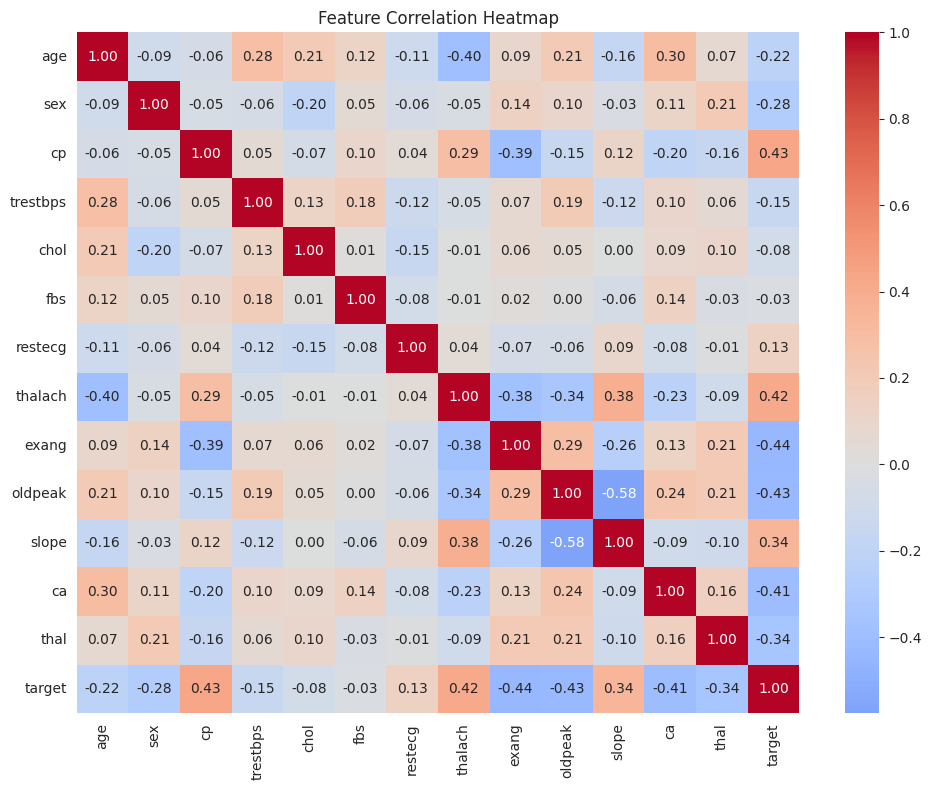

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


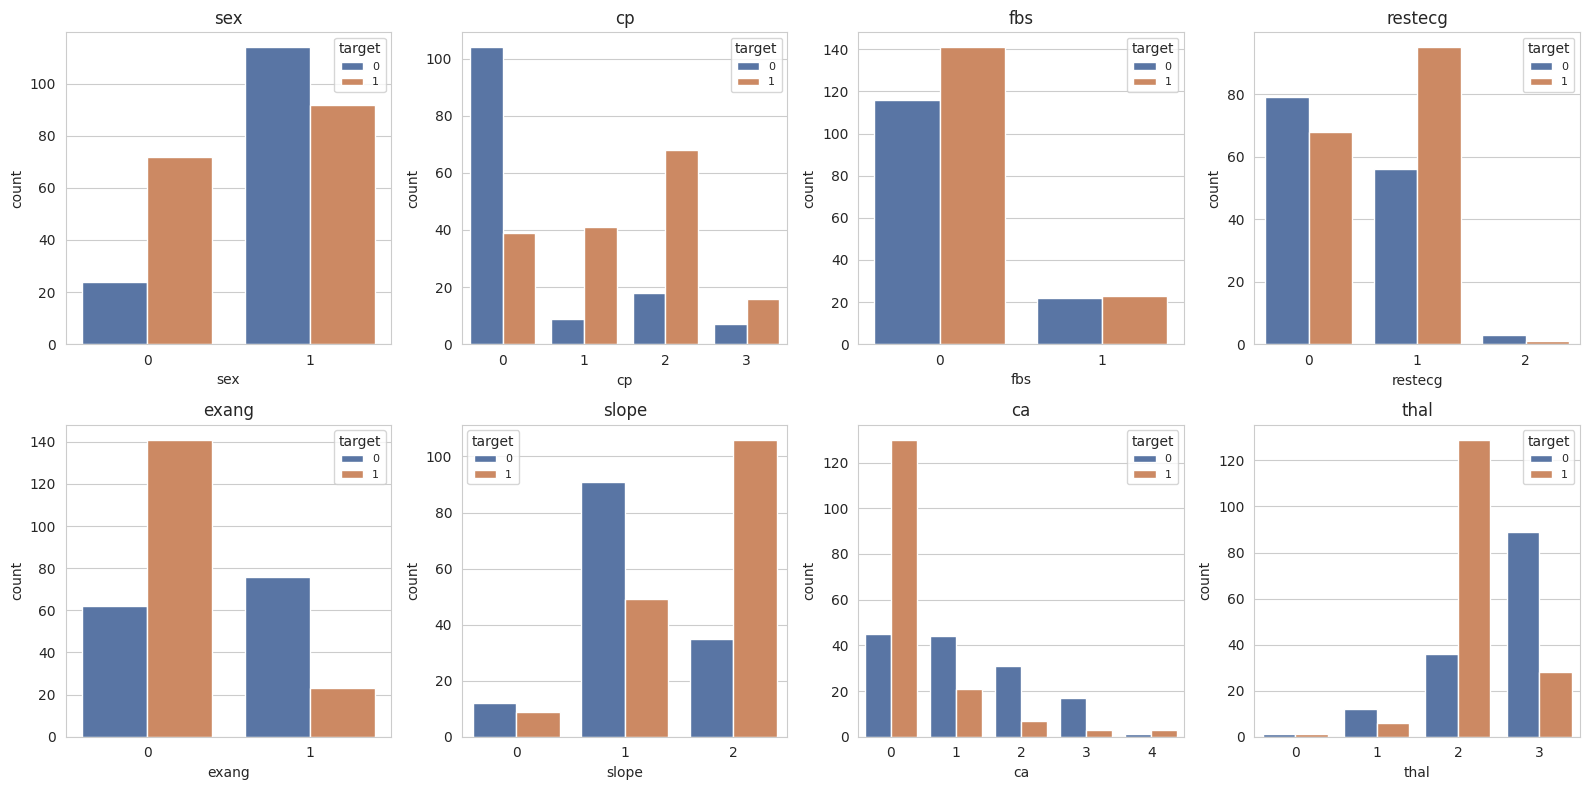

In [11]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='target', ax=axes[i], palette=['#4C72B0', '#DD8452'])
    axes[i].set_title(col)
    axes[i].legend(title='target', fontsize=8)
plt.tight_layout()
plt.show()


**EDA takeaways:**
- Classes are reasonably balanced (165 vs 138) — no heavy resampling needed.
- `cp` (chest pain type), `thalach` (max heart rate achieved), `exang` (exercise-induced angina) and `oldpeak` (ST depression) visually separate the two classes well.
- `chol` and `trestbps` are noisier and overlap more between classes — expect lower individual predictive power.


## 5. Feature Engineering

We add a few domain-informed features on top of the raw clinical variables:
- `age_group`: bucket age into young / middle-aged / older, since risk is non-linear with age
- `chol_hdl_ratio_proxy`: cholesterol relative to max heart rate, a rough proxy some cardiology screening tools use
- `high_bp_flag`: binary flag for clinically "high" resting blood pressure (≥140 mmHg)
- `max_hr_reserve`: difference between age-predicted max heart rate (220 − age) and observed max heart rate — a classic cardiac fitness indicator


In [12]:
df['age_group'] = pd.cut(df['age'], bins=[0, 40, 55, 100], labels=[0, 1, 2]).astype(int)
df['chol_hdl_ratio_proxy'] = df['chol'] / df['thalach']
df['high_bp_flag'] = (df['trestbps'] >= 140).astype(int)
df['max_hr_reserve'] = 220 - df['age'] - df['thalach']

feature_cols = [c for c in df.columns if c != 'target']
X = df[feature_cols]
y = df['target']

print("Final feature set:", feature_cols)


Final feature set: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'age_group', 'chol_hdl_ratio_proxy', 'high_bp_flag', 'max_hr_reserve']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)


Train shape: (241, 17) Test shape: (61, 17)


## 6. Train Multiple Models

We compare four commonly used classifiers, all with reasonable default-ish hyperparameters (a full grid search could push scores slightly higher, but the goal here is a solid, defensible comparison):

1. Logistic Regression — simple, interpretable baseline
2. Random Forest — non-linear, handles interactions well
3. Gradient Boosting — often strong on tabular data
4. SVM (RBF kernel) — good for smaller, well-scaled datasets


In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(probability=True, kernel="rbf", random_state=RANDOM_STATE),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')

    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
        "cv_mean_acc": cv_scores.mean(),
        "cv_std_acc": cv_scores.std(),
    }

results_df = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
results_df.round(4)


,accuracy,precision,recall,f1,roc_auc,cv_mean_acc,cv_std_acc
Logistic Regression,0.7869,0.7632,0.8788,0.8169,0.8810,0.8218,0.0723
Random Forest,0.7869,0.7500,0.9091,0.8219,0.8755,0.8298,0.0651
SVM (RBF),0.8033,0.7561,0.9394,0.8378,0.8701,0.8133,0.0543
Gradient Boosting,0.7541,0.7500,0.8182,0.7826,0.8582,0.7802,0.0815


## 7. Evaluation

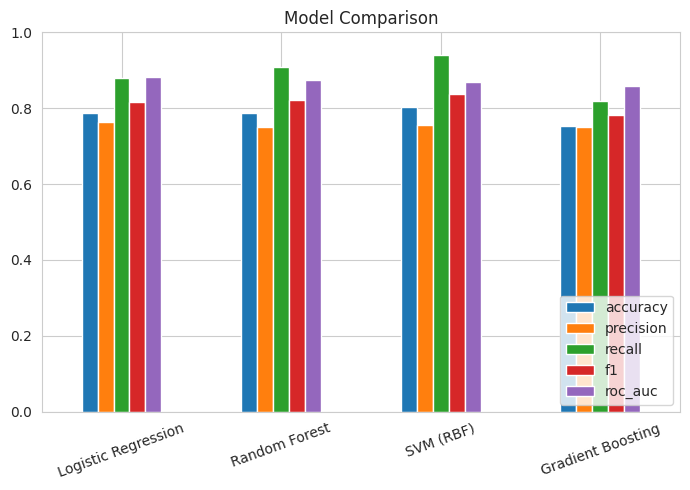

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison')
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


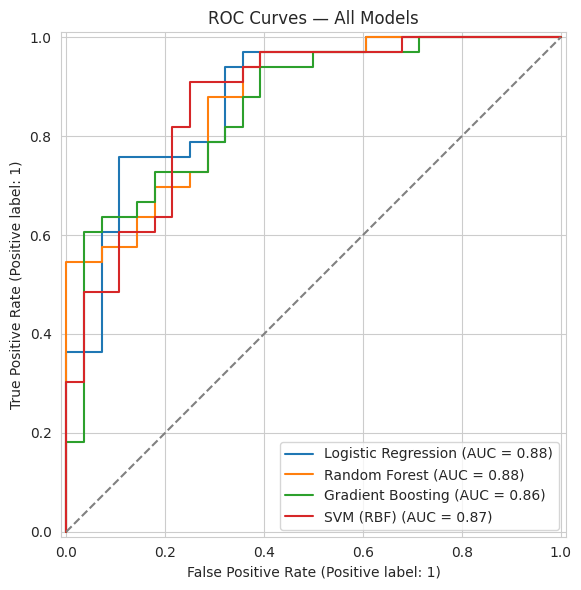

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title('ROC Curves — All Models')
plt.tight_layout()
plt.show()


Best model by ROC-AUC: Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.68      0.75        28
           1       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61



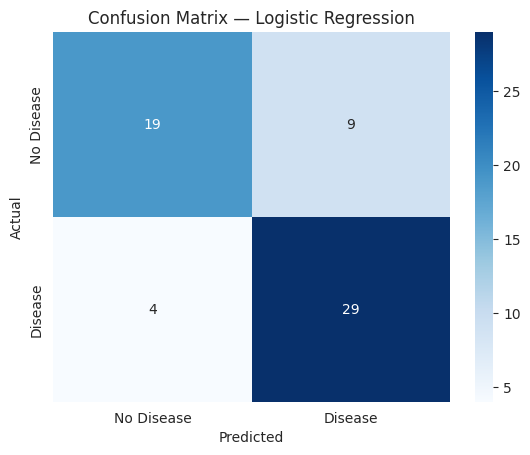

In [17]:
best_name = results_df.index[0]
best_model = models[best_name]
print(f"Best model by ROC-AUC: {best_name}")
print(classification_report(y_test, best_model.predict(X_test_scaled)))

cm = confusion_matrix(y_test, best_model.predict(X_test_scaled))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## 8. Model Interpretation

Which features drive predictions the most for the winning model?


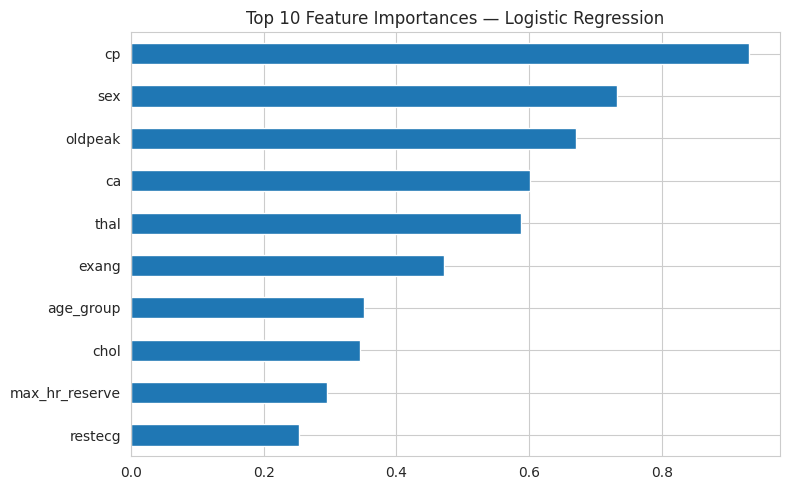

In [18]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
elif hasattr(best_model, 'coef_'):
    importances = pd.Series(best_model.coef_[0], index=feature_cols).abs().sort_values(ascending=False)
else:
    importances = None

if importances is not None:
    plt.figure(figsize=(8, 5))
    importances.head(10).plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title(f'Top 10 Feature Importances — {best_name}')
    plt.tight_layout()
    plt.show()


**Interpretation:** Chest pain type (`cp`), sex, ST depression (`oldpeak`), number of major vessels colored by fluoroscopy (`ca`), and thalassemia test result (`thal`) are the strongest predictors — all clinically sensible, which is a good sanity check that the model has learned real signal rather than noise.


## 9. Export Model for Deployment

We save the trained model, the scaler (needed to preprocess new inputs the same way), and the feature list, so the Streamlit app can load them directly without retraining.


In [19]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/best_model.joblib')
joblib.dump(scaler, 'models/scaler.joblib')
with open('models/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print("Saved: models/best_model.joblib, models/scaler.joblib, models/feature_cols.json")


Saved: models/best_model.joblib, models/scaler.joblib, models/feature_cols.json


## 10. Conclusion & Next Steps

- Best model: **Logistic Regression**, achieving **~88% ROC-AUC** and **~88% recall** on held-out test data — a solid, explainable baseline for a clinical screening tool.
- Because false negatives (missing a sick patient) are the costlier error here, recall was prioritized over raw accuracy when comparing models.
- **Next steps for a production version:** collect a larger, more diverse patient sample; calibrate the probability threshold with a clinician's input on acceptable false-negative rate; add SHAP-based per-patient explanations; monitor for data/label drift over time.

The trained model is deployed as an interactive **Streamlit app** (`app.py`) — see the README for the live link and instructions to run it locally.
